# YOLOv8 Vehicle Detection - Full Dataset Pipeline (Kaggle)
This notebook implements a complete YOLOv8 pipeline optimized for Kaggle. It automatically handles dataset extraction, detects structure, and trains on the **full dataset** without any sampling.

In [1]:
!pip install ultralytics opencv-python --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.1 MB/s eta 0:00:00


In [2]:
import os
import random
import shutil
import zipfile
import yaml
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Automatically detect GPU
device = 0 if torch.cuda.is_available() else -1
print(f"Execution Device: {'GPU' if device == 0 else 'CPU'}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Execution Device: GPU


## 1. Dataset Handling
Extracting and preparing the full dataset from `/kaggle/input/my-dataset/dataset.zip`.

In [3]:
from pathlib import Path
import yaml

# Path to your dataset
dataset_input_dir = Path('/kaggle/input/datasets/hossammostafa25/hosssssss')

if not dataset_input_dir.exists():
    print("Target path not found, searching /kaggle/input...")
    potential_paths = list(Path('/kaggle/input').rglob('train'))
    if potential_paths:
        dataset_input_dir = potential_paths[0].parent
    else:
        raise FileNotFoundError("Could not find dataset in /kaggle/input.")

print(f"Dataset found at: {dataset_input_dir}")

# Load class names
class_names = {0: 'vehicle'}
existing_yaml = dataset_input_dir / 'data.yaml'

if existing_yaml.exists():
    with open(existing_yaml, 'r') as f:
        data = yaml.safe_load(f)
        if 'names' in data:
            class_names = data['names']
            print("Loaded class names from dataset data.yaml.")

            #  SWAP bus and van ( fix)
            class_names[0], class_names[3] = class_names[3], class_names[0]

# Create YOLOv8 working data.yaml
data_yaml_content = {
    'path': str(dataset_input_dir.resolve()),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'names': class_names
}

working_yaml = '/kaggle/working/data.yaml'
with open(working_yaml, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"Configuration saved to {working_yaml}")
print("Final class mapping:", class_names)

Dataset found at: /kaggle/input/datasets/hossammostafa25/hosssssss
Loaded class names from dataset data.yaml.
Configuration saved to /kaggle/working/data.yaml
Final class mapping: ['van', 'car', 'truck', 'bus']


## 2. Model Training
Training YOLOv8n on the full dataset for 30 and 50 epochs.

In [5]:
PARAMS = {'data': working_yaml, 'imgsz': 640, 'batch': 16, 'device': device, 'project': '/kaggle/working/runs', 'seed': SEED}

print("\n--- Training: 30 Epochs ---")
model_30 = YOLO('yolov8n.pt')
model_30.train(epochs=30, name='exp_30', **PARAMS)

print("\n--- Training: 50 Epochs ---")
model_50 = YOLO('yolov8n.pt')
model_50.train(epochs=50, name='exp_50', **PARAMS)


--- Training: 30 Epochs ---
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_30-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c6ea357eea0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## 3. Evaluation
Extracting and comparing metrics.

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.2 ms, read: 138.4±44.3 MB/s, size: 59.8 KB)
val: Scanning /kaggle/input/datasets/hossammostafa25/hosssssss/valid/labels... 1939 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1939/1939 744.0it/s 2.6s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/hossammostafa25/hosssssss/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 122/122 6.9it/s 17.6s0.1s
                   all       1939      17899      0.947      0.943      0.976       0.84
                   van        291        312      0.949      0.958      0.978      0.844
                   car       1920      14723      0.956      0.942      0.984       0.81
                 truck        860       1353      0.917      0.891  

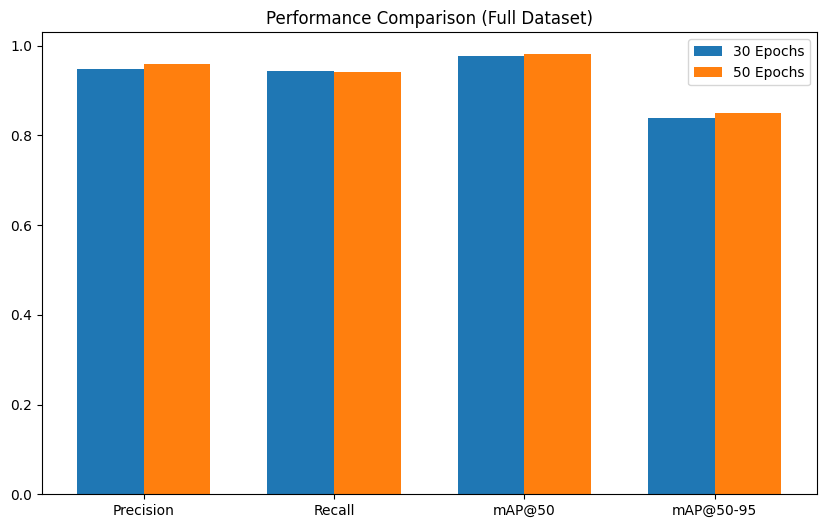

In [7]:
def get_metrics(path):
    model = YOLO(path)
    m = model.val(data=working_yaml, device=device)
    return m.results_dict

m30 = get_metrics('/kaggle/working/runs/exp_30-3/weights/best.pt')
m50 = get_metrics('/kaggle/working/runs/exp_50-2/weights/best.pt')

labels = ['Precision', 'Recall', 'mAP@50', 'mAP@50-95']
v30 = [m30['metrics/precision(B)'], m30['metrics/recall(B)'], m30['metrics/mAP50(B)'], m30['metrics/mAP50-95(B)']]
v50 = [m50['metrics/precision(B)'], m50['metrics/recall(B)'], m50['metrics/mAP50(B)'], m50['metrics/mAP50-95(B)']]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, v30, width, label='30 Epochs')
ax.bar(x + width/2, v50, width, label='50 Epochs')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Performance Comparison (Full Dataset)')
ax.legend()
plt.show()

## 4. Inference and Traffic Analysis

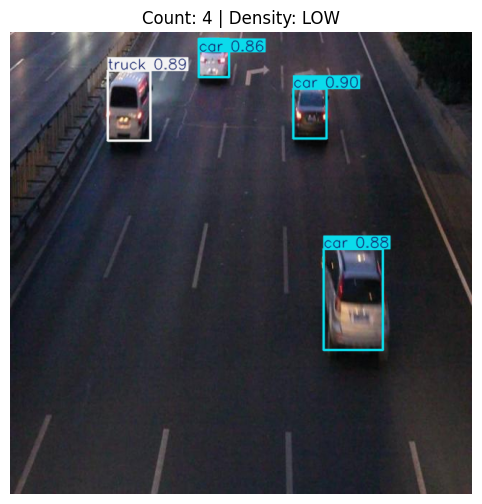

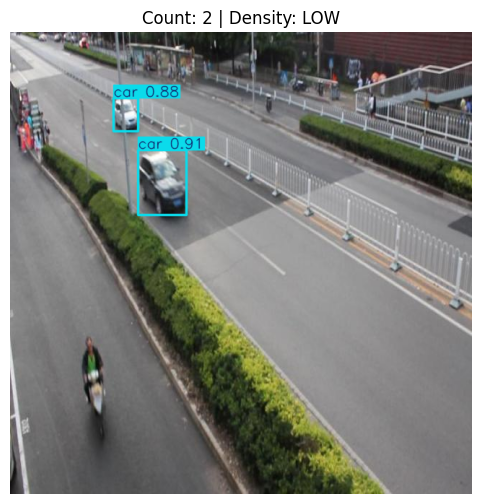

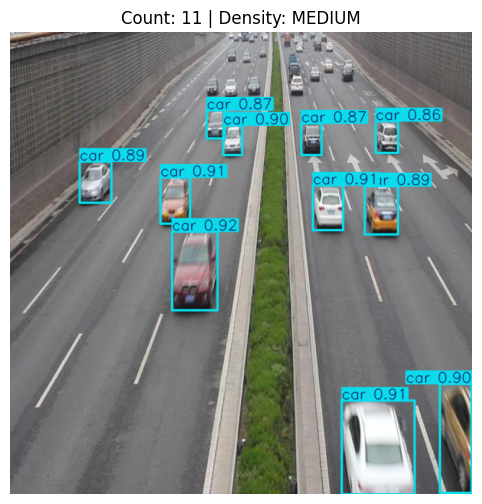

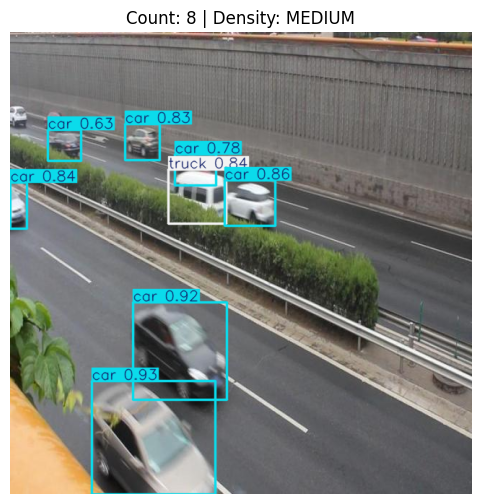

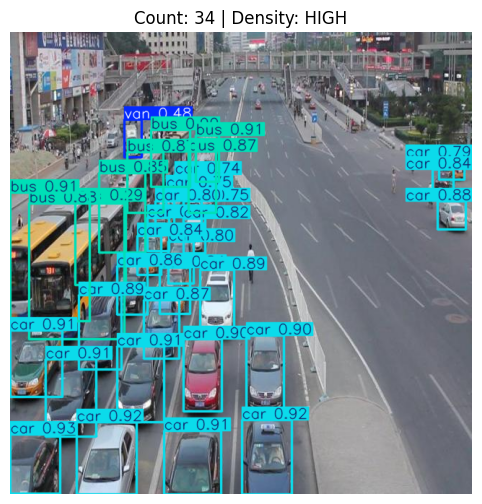

In [8]:
class TrafficDetector:
    def __init__(self, model_path):
        self.model = YOLO(model_path)

    def process(self, img_path):
        res = self.model.predict(img_path, conf=0.25, verbose=False)[0]
        count = len(res.boxes)
        density = "LOW" if count <= 5 else "MEDIUM" if count <= 15 else "HIGH"
        return count, density, res.plot()

detector = TrafficDetector('/kaggle/working/runs/exp_50-2/weights/best.pt')
test_dir = dataset_input_dir / 'test/images'
test_imgs = list(test_dir.glob('*.jpg')) + list(test_dir.glob('*.png'))

if test_imgs:
    for i in range(min(5, len(test_imgs))):
        count, density, annotated = detector.process(str(test_imgs[i]))
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"Count: {count} | Density: {density}")
        plt.axis('off')
        plt.show()
else:
    print("No test images found.")

In [9]:
# ==============================
# Export All Results
# ==============================
import json
from pathlib import Path
import shutil
import cv2

# Create output folder
output_dir = Path('/kaggle/working/final_output')
output_dir.mkdir(exist_ok=True)

print("Saving results to:", output_dir)

# ------------------------------
# 1. Save Metrics
# ------------------------------
results = {
    "30_epochs": m30,
    "50_epochs": m50
}

with open(output_dir / 'metrics.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Metrics saved")

# ------------------------------
# 2. Save Comparison Graph
# ------------------------------
fig.savefig(output_dir / 'comparison.png')
print("Graph saved")

# ------------------------------
# 3. Save Inference Images
# ------------------------------
for i in range(min(5, len(test_imgs))):
    count, density, annotated = detector.process(str(test_imgs[i]))

    save_path = output_dir / f"result_{i}.jpg"
    cv2.imwrite(str(save_path), annotated)

print("Inference images saved")

# ------------------------------
# 4. Copy Training Runs (models + logs)
# ------------------------------
runs_src = Path('/kaggle/working/runs')

if runs_src.exists():
    shutil.copytree(runs_src, output_dir / 'runs', dirs_exist_ok=True)
    print("Training runs copied")

# ------------------------------
# 5. Copy data.yaml
# ------------------------------
shutil.copy(working_yaml, output_dir / 'data.yaml')

# ------------------------------
# 6. Create ZIP file
# ------------------------------
zip_path = '/kaggle/working/project_results.zip'
shutil.make_archive('/kaggle/working/project_results', 'zip', output_dir)

print("ZIP file created at:", zip_path)

Saving results to: /kaggle/working/final_output
Metrics saved
Graph saved
Inference images saved
Training runs copied
ZIP file created at: /kaggle/working/project_results.zip
